In [1]:
# === Import necessary libraries ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


In [2]:
# === Load the dataset ===
df = pd.read_csv("covid_19_india.csv")
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

C:\Users\Sumi\AppData\Local\Temp\ipykernel_17060\4016936273.py:3: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)


In [3]:
# === Aggregate data ===
df = df.groupby('Date')[['Confirmed', 'Cured', 'Deaths']].sum().reset_index()

# === Create new cases column ===
df['New_Cases'] = df['Confirmed'].diff().fillna(0)
df['New_Cases'] = df['New_Cases'].apply(lambda x: x if x > 0 else 0)


In [4]:

# === Create lag features ===
df['Lag_1'] = df['New_Cases'].shift(1)
df['Lag_7'] = df['New_Cases'].shift(7)
df['Lag_14'] = df['New_Cases'].shift(14)
df = df.dropna()

# === Time range and splitting into two halves ===
min_date = df['Date'].min()
max_date = df['Date'].max()

# Find the midpoint date
mid_date = min_date + (max_date - min_date) / 2

# Split the data into two halves
df_first_half = df[df['Date'] <= mid_date]
df_second_half = df[df['Date'] > mid_date]

# Filter data for the first half (2020-02 to 2020-10)
df_first_half = df[(df['Date'] >= '2020-02-01') & (df['Date'] <= '2020-10-31')]


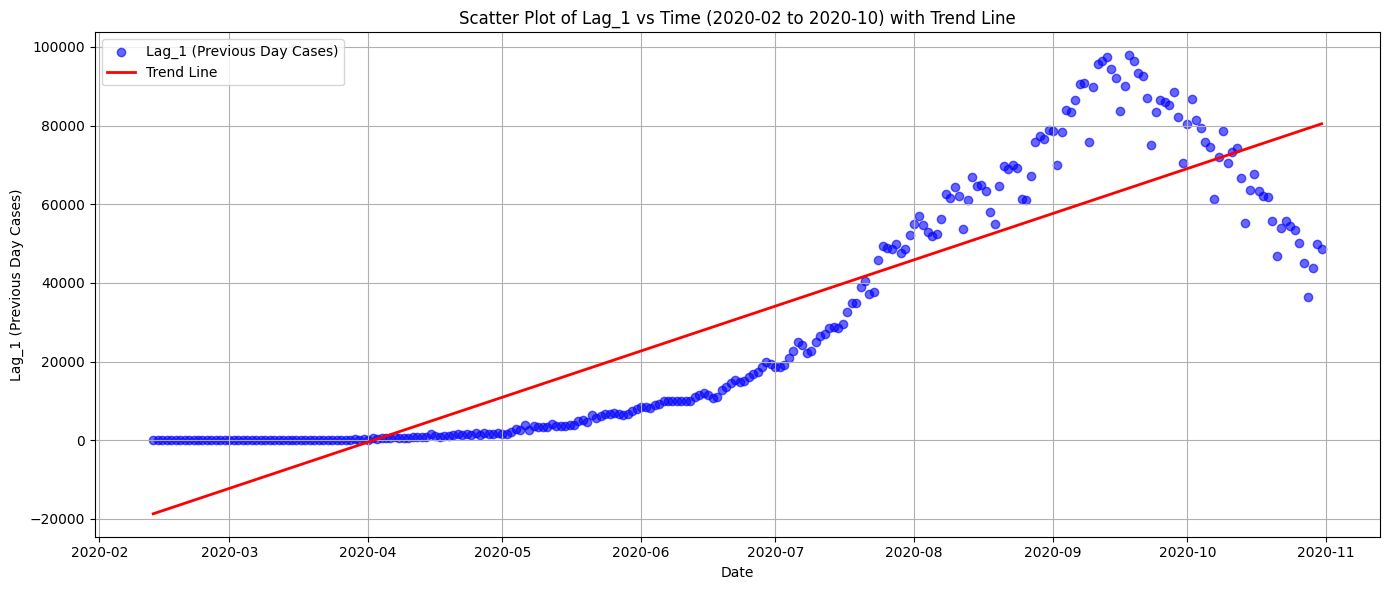

In [9]:

# Scatter plot for Lag_1 vs Time in the first half
plt.figure(figsize=(14, 6))
plt.scatter(df_first_half['Date'], df_first_half['Lag_1'], color='blue', alpha=0.6, label="Lag_1 (Previous Day Cases)")

# Fit a linear trend line for visualization
trend_model = LinearRegression()
date_ordinal = np.array(df_first_half['Date'].map(pd.Timestamp.toordinal)).reshape(-1, 1)
trend_model.fit(date_ordinal, df_first_half['Lag_1'])
line_trend = trend_model.predict(date_ordinal)
# Plot regression line
plt.plot(df_first_half['Date'], line_trend, color='red', linewidth=2, label="Trend Line")
# Labels and aesthetics
plt.xlabel("Date")
plt.ylabel("Lag_1 (Previous Day Cases)")
plt.title("Scatter Plot of Lag_1 vs Time (2020-02 to 2020-10) with Trend Line")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
# === 2. Actual vs Predicted Plot (Second Half) ===
# Define features (X) and target for second half
X_second_half = df_second_half[['Lag_1']]  # Only one feature as per your request
y_second_half = df_second_half['New_Cases']
dates_second_half = df_second_half['Date']

# Split the second half into training and testing sets
X_train_second_half, X_test_second_half, y_train_second_half, y_test_second_half, dates_train_second_half, dates_test_second_half = train_test_split(
    X_second_half, y_second_half, dates_second_half, test_size=0.2, shuffle=False
)

In [ ]:

# Split the second half into X and y (features and target)
X_second_half = df_second_half[['Lag_1']]  # Only using Lag_1
y_second_half = df_second_half['New_Cases']


In [11]:
# Train the Linear Regression model on the second half
lr_model_second_half = LinearRegression()
lr_model_second_half.fit(X_train_second_half, y_train_second_half)
y_pred_lr_second_half = lr_model_second_half.predict(X_test_second_half)
# Filter data for the second half (2020-11 to 2021-08)
df_second_half = df[(df['Date'] >= '2020-11-01') & (df['Date'] <= '2021-08-11')]


In [22]:

# Get the intercept and coefficient from the trained model
intercept = lr_model_second_half.intercept_
coefficient = lr_model_second_half.coef_[0]  # Since we have one feature (Lag_1)


In [18]:
# Print the equation of the linear regression model
print(f"Linear Regression Equation: y = {612.17:.2f} + ({0.99:.2f}) * Lag_1")

# Use the given equation to predict values
df_second_half['Predicted_New_Cases'] = 612.17 + 0.99 * df_second_half['Lag_1']

# Create a table with Date, Lag_1 and Predicted_New_Cases
table = df_second_half[['Date', 'Lag_1', 'Predicted_New_Cases']]

# Display the first 20 rows of the table
print(table.head(40))


Linear Regression Equation: y = 612.17 + (0.99) * Lag_1
          Date    Lag_1  Predicted_New_Cases
276 2020-11-01  48268.0             48397.49
277 2020-11-02  46963.0             47105.54
278 2020-11-03  45231.0             45390.86
279 2020-11-04  38310.0             38539.07
280 2020-11-05  46253.0             46402.64
281 2020-11-06  50210.0             50320.07
282 2020-11-07  47638.0             47773.79
283 2020-11-08  50356.0             50464.61
284 2020-11-09  45674.0             45829.43
285 2020-11-10  45903.0             46056.14
286 2020-11-11  38073.0             38304.44
287 2020-11-12  44281.0             44450.36
288 2020-11-13  47905.0             48038.12
289 2020-11-14  44879.0             45042.38
290 2020-11-15  44684.0             44849.33
291 2020-11-16  41100.0             41301.17
292 2020-11-17  30548.0             30854.69
293 2020-11-18  29163.0             29483.54
294 2020-11-19  38617.0             38843.00
295 2020-11-20  45576.0             45732.41

C:\Users\Sumi\AppData\Local\Temp\ipykernel_17060\807548133.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_second_half['Predicted_New_Cases'] = 612.17 + 0.99 * df_second_half['Lag_1']


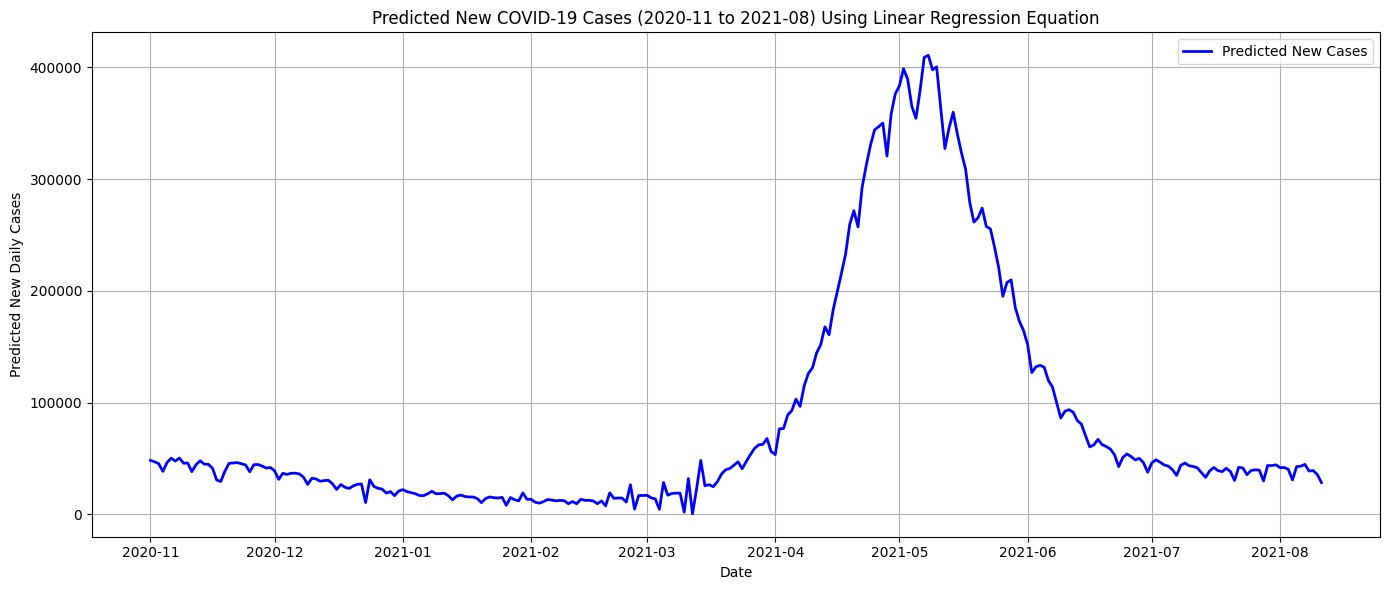

In [19]:

# === Plot the predicted values ===
plt.figure(figsize=(14, 6))
plt.plot(df_second_half['Date'], df_second_half['Predicted_New_Cases'], label="Predicted New Cases", color='blue', linewidth=2)

# Labels and aesthetics
plt.xlabel("Date")
plt.ylabel("Predicted New Daily Cases")
plt.title("Predicted New COVID-19 Cases (2020-11 to 2021-08) Using Linear Regression Equation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


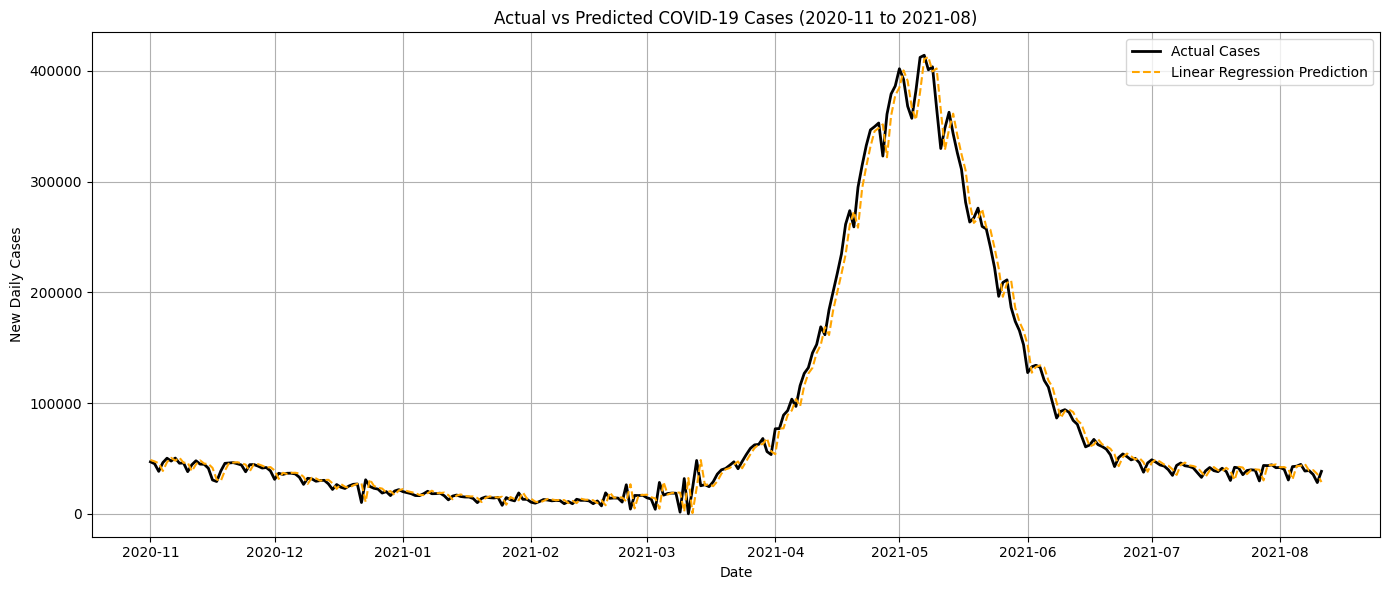

In [20]:

# Use the same Linear Regression model for prediction
y_pred_second_half = lr_model_second_half.predict(X_second_half)

# === Actual vs Predicted Plot for Second Half ===
plt.figure(figsize=(14, 6))
plt.plot(df_second_half['Date'], y_second_half.values, label="Actual Cases", color='black', linewidth=2)
plt.plot(df_second_half['Date'], y_pred_second_half, label="Linear Regression Prediction", linestyle='--', color='orange')

# Labels and aesthetics
plt.xlabel("Date")
plt.ylabel("New Daily Cases")
plt.title("Actual vs Predicted COVID-19 Cases (2020-11 to 2021-08)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
